# 02 - Entanglement and multi-qubit circuits

Two qubits live in H_A tensor H_B, a 4-dimensional space. The computational basis is {|00>, |01>, |10>, |11>}. A state is entangled iff it cant be written as a product |phi>_A tensor |chi>_B - equivalently, iff its Schmidt rank is greater than 1, equivalently, iff the reduced state of either subsystem is mixed.

The interesting thing from a computational standpoint is that entanglement is what makes quantum circuits hard to simulate classically - a general n-qubit state needs 2^n complex amplitudes, and entangled states are the ones that actually use all of them.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace, entropy
from qiskit.visualization import plot_histogram

import warnings
warnings.filterwarnings('ignore')

sim = AerSimulator()

## Tensor products

The joint state of two independent qubits is just the tensor product. In matrix form:
$$|a\rangle \otimes |b\rangle = \begin{pmatrix}a_0 b_0 \\ a_0 b_1 \\ a_1 b_0 \\ a_1 b_1\end{pmatrix}$$

Two-qubit gates are also 4x4 matrices acting on this space. The CNOT is the most important one:
$$\text{CNOT} = |0\rangle\langle 0| \otimes I + |1\rangle\langle 1| \otimes X$$

It flips the target qubit conditioned on the control. Applied after H on the control, it generates entanglement.

In [2]:
ket0 = np.array([1,0], dtype=complex)
ket1 = np.array([0,1], dtype=complex)

CNOT = np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]], dtype=complex)

print('CNOT|00> =', CNOT @ np.kron(ket0,ket0))  # |00>
print('CNOT|10> =', CNOT @ np.kron(ket1,ket0))  # |11>

CNOT|00> = [1.+0.j 0.+0.j 0.+0.j 0.+0.j]
CNOT|10> = [0.+0.j 0.+0.j 0.+0.j 1.+0.j]


## Bell states

The four Bell states are the maximally entangled 2-qubit states:

$$|\Phi^\pm\rangle = \frac{|00\rangle \pm |11\rangle}{\sqrt{2}}, \quad |\Psi^\pm\rangle = \frac{|01\rangle \pm |10\rangle}{\sqrt{2}}$$

They form an orthonormal basis (the Bell basis). The standard circuit for |Phi+> is H on the control followed by CNOT.

[0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]


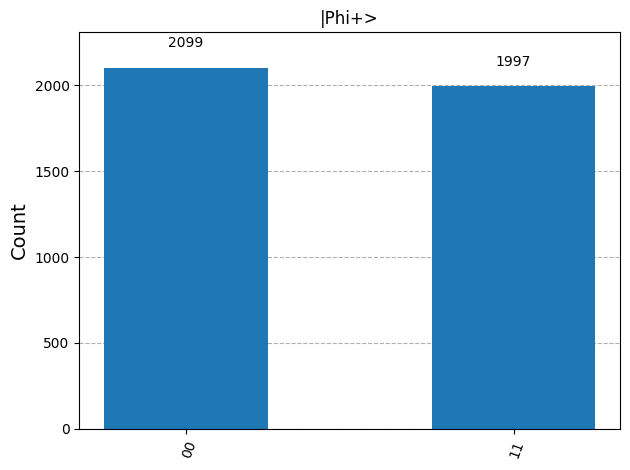

In [3]:
def bell_state(which='Phi+'):
    qc = QuantumCircuit(2)
    if which in ('Phi-', 'Psi-'):
        qc.x(0)
    qc.h(0)
    qc.cx(0, 1)
    if which in ('Psi+', 'Psi-'):
        qc.x(1)
    return qc

qc_bell = bell_state('Phi+')
sv = Statevector(qc_bell)
print(sv.data)  # [1/sqrt2, 0, 0, 1/sqrt2]

qc_bell.measure_all()
counts = sim.run(qc_bell, shots=4096).result().get_counts()
plot_histogram(counts, title='|Phi+>')

Only 00 and 11 appear - the two qubits are perfectly correlated regardless of which qubit is measured first. This is stronger than any classical correlation, which is what Bell inequalities quantify.

## Entanglement entropy

For a pure state, entanglement is captured by the von Neumann entropy of either reduced state. If the state is a product, tracing out one qubit leaves a pure state with S=0. If its maximally entangled, tracing out gives the maximally mixed state (I/2) with S=1 bit.

In [4]:
# Bell state - trace out qubit 1
qc_phi = bell_state('Phi+')
rho_A = partial_trace(DensityMatrix(qc_phi), [1])
print('Bell state entropy:', entropy(rho_A, base=2))  # should be 1.0

# product state |+0> - trace out qubit 1
qc_prod = QuantumCircuit(2)
qc_prod.h(0)
rho_A_prod = partial_trace(DensityMatrix(qc_prod), [1])
print('product state entropy:', entropy(rho_A_prod, base=2))  # should be 0

Bell state entropy: 1.0
product state entropy: 1.4415419267167124e-15


## Quantum teleportation

Alice has an unknown state |psi> = alpha|0> + beta|1> and wants to send it to Bob. They share a Bell pair. The protocol:

1. Alice entangles her qubit with her half of the pair, then measures both - gets 2 classical bits
2. She sends those bits to Bob over a classical channel
3. Bob applies X and/or Z depending on the bits
4. Bobs qubit is now in |psi>

The state is destroyed at Alices end (no-cloning is safe). No quantum channel is needed after the Bell pair is distributed.

In qiskit classical control is done with c_if - apply a gate conditioned on the value of a classical register.

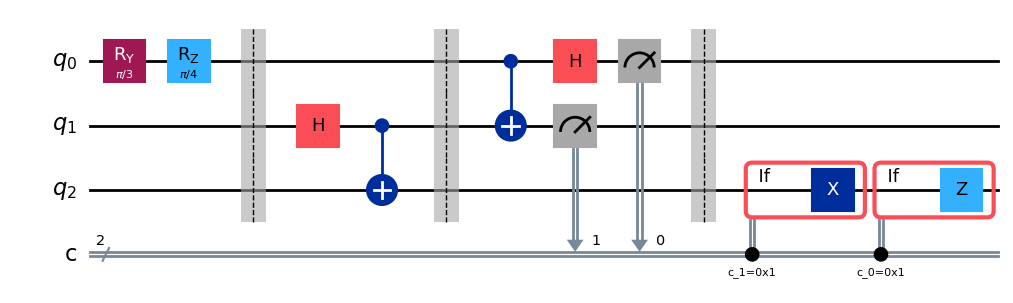

In [12]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

def teleportation_circuit(theta, phi):
    # qubit 0: Alices message, qubit 1: Alices Bell half, qubit 2: Bobs half
    qr = QuantumRegister(3, 'q')
    cr = ClassicalRegister(2, 'c')
    qc = QuantumCircuit(qr, cr)

    # state to teleport
    qc.ry(theta, 0)
    qc.rz(phi, 0)
    qc.barrier()

    # Bell pair between 1 and 2
    qc.h(1)
    qc.cx(1, 2)
    qc.barrier()

    # Alices operations
    qc.cx(0, 1)
    qc.h(0)
    qc.measure([0, 1], [0, 1])
    qc.barrier()

    # Bobs corrections (Sintaxis corregida)
    # cr[1] controla la puerta X, cr[0] controla la puerta Z
    with qc.if_test((cr[1], 1)):
        qc.x(2)
        
    with qc.if_test((cr[0], 1)):
        qc.z(2)

    return qc
teleportation_circuit(np.pi/3, np.pi/4).draw('mpl', fold=20)

In [13]:
# verify: teleport then un-prepare on Bobs side, should always measure |0>
theta, phi = np.pi/3, np.pi/4

qr = QuantumRegister(3)
cr = ClassicalRegister(3)
qc_v = QuantumCircuit(qr, cr)

qc_v.ry(theta, 0)
qc_v.rz(phi, 0)
qc_v.h(1)
qc_v.cx(1, 2)
qc_v.cx(0, 1)
qc_v.h(0)
qc_v.measure([0, 1], [0, 1])

# Corrección de las correcciones de Bob
with qc_v.if_test((cr[1], 1)):
    qc_v.x(2)
with qc_v.if_test((cr[0], 1)):
    qc_v.z(2)

# un-prepare: apply inverse of the original state prep
qc_v.rz(-phi, 2)
qc_v.ry(-theta, 2)
qc_v.measure(2, 2)

# Ejecución (asegúrate de que 'sim' esté definido, e.g., AerSimulator())
job = sim.run(qc_v, shots=4096)
counts = job.result().get_counts()

# En Qiskit el bitstring se lee de derecha a izquierda: q2 q1 q0
# Si medimos el bit 2 (Bob), es el primer carácter del string (el de la izquierda)
success = sum(v for k, v in counts.items() if k[0] == '0')
print(f'Bobs qubit in |0> after un-prep: {100*success/4096:.1f}%')

Bobs qubit in |0> after un-prep: 100.0%


## Superdense coding

The dual protocol: using one qubit of quantum communication (plus a pre-shared Bell pair), Alice can send 2 classical bits to Bob. She encodes the 2 bits by applying one of {I, X, Z, XZ} to her qubit, then sends it. Bob decodes by measuring in the Bell basis.

Two classical bits from one qubit - only possible because of the shared entanglement.

In [15]:
def superdense(message):
    assert message in ('00','01','10','11')
    qc = QuantumCircuit(2, 2)
    qc.h(0); qc.cx(0,1)  # shared Bell pair
    qc.barrier()
    if message[1] == '1': qc.x(0)  # encode second bit
    if message[0] == '1': qc.z(0)  # encode first bit
    qc.barrier()
    qc.cx(0,1); qc.h(0)  # decode
    qc.measure([0,1],[0,1])
    return qc

for msg in ['00','01','10','11']:
    counts = sim.run(superdense(msg), shots=512).result().get_counts()
    # Al imprimir, le damos la vuelta al string de salida [::-1]
    decoded = max(counts, key=counts.get)[::-1] 
    print(f'sent {msg} -> decoded {decoded}')

sent 00 -> decoded 00
sent 01 -> decoded 01
sent 10 -> decoded 10
sent 11 -> decoded 11
